In [1]:
# import essential
import sys
from pathlib import Path

MODULE_PATH = Path("/root/capsule/src/aind_dft_ephys_analysis")

if str(MODULE_PATH) not in sys.path:
    sys.path.insert(0, str(MODULE_PATH))



In [ ]:
# run in parallel

import multiprocessing as mp
from pathlib import Path

from general_utils import find_ephys_sessions
from monotonic_mp import run_all_sessions_parallel

# IMPORTANT in notebooks
try:
    mp.set_start_method("spawn", force=True)
except RuntimeError:
    pass

PSTH_DIR = Path("/root/capsule/scratch/psth_results")
RESULTS_DIR = Path("/root/capsule/scratch/behavior_summary")
OUT_DIR = Path("/root/capsule/scratch/monotonic_outputs_n_4")

LATENT_NAMES = [
    "ForagingCompareThreshold-value-1",
    "QLearning_L2F1_softmax-deltaQ-1",
    "QLearning_L2F1_softmax-sumQ-1",
]

ACTIVITY_WINDOWS = [(-1, 0), (0.2, 2),(-3,0)]

_, _, sessions = find_ephys_sessions()


_results = run_all_sessions_parallel(
    list(sessions),
    psth_dir=PSTH_DIR,
    results_dir=RESULTS_DIR,
    out_dir=OUT_DIR,
    latent_names=LATENT_NAMES,
    activity_windows=ACTIVITY_WINDOWS,
    max_workers=4,   # scale up later if stable
)


failed = [r for r in _results if not r.get("ok", False)]

print(f"Failed sessions: {len(failed)}")

failed_sessions = [r.get("session") for r in failed]
print(failed_sessions[:20])

sessions=failed_sessions
_results = run_all_sessions_parallel(
    list(sessions),
    psth_dir=PSTH_DIR,
    results_dir=RESULTS_DIR,
    out_dir=OUT_DIR,
    latent_names=LATENT_NAMES,
    activity_windows=ACTIVITY_WINDOWS,
    max_workers=4,   # scale up later if stable
)

In [2]:
# Load summary (as you already do)
# -----------------------------
import importlib
import behavior_qc_visualization

importlib.reload(behavior_qc_visualization)


from behavior_qc_visualization import load_behavior_model_summary_csv
from behavior_qc_metrics_summary import append_model_criteria_result

summary = load_behavior_model_summary_csv(
    "/root/capsule/scratch/behavior_model_summary_ephys_sessions.csv"
    # "/root/capsule/scratch/behavior_model_summary_general_behavior.csv"
)
summary = append_model_criteria_result(summary)


# -----------------------------
# Load combined_df + summarize (UPDATED: add summary + criteria_col)
# -----------------------------
from check_monotonic import load_and_combine_monotonic_unit_dfs
from check_monotonic import summarize_significant_and_monotonic_fractions

combined_df = load_and_combine_monotonic_unit_dfs(
    "/root/capsule/scratch/monotonic_outputs_n_4/ForagingCompareThreshold-value-1/win_m1__0",
    pattern="*.csv",
    recursive=True,
    add_source_file=True,
)
print("combined_df shape (before filtering inside function):", combined_df.shape)

out = summarize_significant_and_monotonic_fractions(
    combined_df,
    alpha=0.05,
    p_col="spearman_p",
    monotonic_col="is_monotonic",
    include_overall=True,
    summary=summary,  # NEW
    # Default criteria_col is 'QLearning_L1F1_CK1_softmax_pass_all_criteria'
    # Override here if you want a different model's criteria:
    # criteria_col="QLearning_L2F1_softmax_pass_all_criteria",
)

# Optional: see how many rows survived the session filter
if out.get("session_filter_applied", False):
    print(
        "Session filter applied:",
        out["criteria_col"],
        "| rows:",
        out["n_rows_before_session_filter"],
        "->",
        out["n_rows_after_session_filter"],
        "| n_sessions_passing:",
        out["n_sessions_passing_criteria"],
    )

overall = out["overall"]
print("Fraction significant (among valid p):", overall["frac_significant_among_valid_p"])
print("Fraction monotonic among significant:", overall["frac_monotonic_among_significant"])
print("n_sig:", overall["n_significant"], "n_sig_monot:", overall["n_significant_and_monotonic"])

sig_df = overall["significant_df"]
sig_monot_df = overall["significant_monotonic_df"]

for label, res in out["by_brain_region_group"].items():
    print(
        label,
        "n_total:", res["n_total_rows"],
        "frac_sig:", res["frac_significant_among_valid_p"],
        "frac_monot|sig:", res["frac_monotonic_among_significant"],
        "n_sig:", res["n_significant"],
        "n_sig_monot:", res["n_significant_and_monotonic"],
    )


combined_df shape (before filtering inside function): (25055, 90)
Session filter applied: QLearning_L1F1_CK1_softmax_pass_all_criteria | rows: 25055 -> 16655 | n_sessions_passing: 26
Fraction significant (among valid p): 0.40246542393265183
Fraction monotonic among significant: 0.441804870760496
n_sig: 6693 n_sig_monot: 2957
[MD] n_total: 2223 frac_sig: 0.40018026137899954 frac_monot|sig: 0.45045045045045046 n_sig: 888 n_sig_monot: 400
[SI,MA] n_total: 462 frac_sig: 0.43383947939262474 frac_monot|sig: 0.41 n_sig: 200 n_sig_monot: 82
[PL5,PL6a,ILA5,ILA6a] n_total: 295 frac_sig: 0.4542372881355932 frac_monot|sig: 0.5373134328358209 n_sig: 134 n_sig_monot: 72
[MOs2/3,MOs5,MOs6a] n_total: 787 frac_sig: 0.49363867684478374 frac_monot|sig: 0.5876288659793815 n_sig: 388 n_sig_monot: 228
[ORBm1,ORBm5,ORBm2/3,ORBm6a] n_total: 247 frac_sig: 0.3805668016194332 frac_monot|sig: 0.44680851063829785 n_sig: 94 n_sig_monot: 42


In [ ]:
out['by_brain_region_group'].keys()

In [35]:
out['by_brain_region_group'][region]['significant_df']

Index(['unit_index', 'session_name', 'latent_name', 'activity_min_threshold',
       'min_average_firing_rate', 'avg_firing_rate_window',
       'calculation_window_start', 'calculation_window_end', 'n_trials_used',
       'n_trials_used_gt_thr', 'n_bins_requested', 'n_bins_effective',
       'binning', 'activity_window_start', 'activity_window_end',
       'quantile_stat', 'ci', 'monotonic_tol', 'is_monotonic',
       'monotonic_direction', 'monotonic_n_valid_bins',
       'monotonic_check_bins_valid', 'monotonic_check_values',
       'monotonic_diffs', 'monotonic_violation_count',
       'monotonic_violation_diffs', 'monotonic_violation_pairs',
       'monotonic_direction_increasing_ok',
       'monotonic_direction_decreasing_ok', 'is_monotonic_gt_thr',
       'monotonic_direction_gt_thr', 'monotonic_n_valid_bins_gt_thr',
       'monotonic_check_bins_valid_gt_thr', 'monotonic_check_values_gt_thr',
       'monotonic_diffs_gt_thr', 'monotonic_violation_count_gt_thr',
       'monotonic_

In [37]:
import numpy as np
import pandas as pd

alpha = 0.05
col = "monotonic_direction_increasing_ok"

regions = [
    '[SI,MA]',
    '[MD]',
    '[MOs2/3,MOs5,MOs6a]',
    '[PL5,PL6a,ILA5,ILA6a]',
]

rows = []

for region in regions:

    # -----------------------------
    # Monotonic increasing fraction
    # -----------------------------
    df_mono = out['by_brain_region_group'][region]['significant_monotonic_df']
    
    n_total_mono = df_mono[col].notna().sum()
    n_true_mono = (df_mono[col] == True).sum()
    frac_mono = n_true_mono / n_total_mono if n_total_mono > 0 else np.nan

    # -----------------------------
    # Positive among significant
    # -----------------------------
    df_sig = out['by_brain_region_group'][region]['significant_df']
    df_sig = df_sig[df_sig['spearman_rho'].notna()]
    sig = df_sig[df_sig['spearman_p'] <= alpha]

    n_total_sig = len(sig)
    n_positive_sig = (sig['spearman_rho'] > 0).sum()
    frac_positive = n_positive_sig / n_total_sig if n_total_sig > 0 else np.nan

    rows.append({
        "region": region,
        "mono_increasing_true": n_true_mono,
        "mono_total": n_total_mono,
        "mono_fraction_increasing": frac_mono,
        "sig_positive": n_positive_sig,
        "sig_total": n_total_sig,
        "sig_fraction_positive": frac_positive,
    })

summary_df = pd.DataFrame(rows)

summary_df


,region,mono_increasing_true,mono_total,mono_fraction_increasing,sig_positive,sig_total,sig_fraction_positive
0,"[SI,MA]",29,82,0.353659,84,200,0.420000
1,[MD],311,400,0.777500,665,888,0.748874
2,"[MOs2/3,MOs5,MOs6a]",123,228,0.539474,198,388,0.510309
3,"[PL5,PL6a,ILA5,ILA6a]",45,72,0.625000,84,134,0.626866


In [ ]:
row = combined_df[
    (combined_df['unit_index'] == 365) &
    (combined_df['brain_region'].isin(['PL5','PL6a','ILA5','ILA6a']))
]

row


In [ ]:
# Example: randomly open 8 significant & monotonic neurons

import importlib
import check_monotonic

# Reload the entire module
importlib.reload(check_monotonic)

from check_monotonic import show_unit_figures_from_df_inline

opened_paths = show_unit_figures_from_df_inline(
    out['by_brain_region_group']['[SI,MA]' ]['significant_monotonic_df'],   # your filtered DataFrame
    root="/root/capsule/scratch/raster_plot",
    session_col="session_name",
    latent_col="latent_name",
    unit_col="unit_index",
    n=100,                        # randomly open 8 figures
    random_state=41,            # reproducible sampling
)

print(f"Opened {len(opened_paths)} figures.")


In [ ]:
# plot single neuron activity

import importlib
import plot_raster

importlib.reload(plot_raster)

from plot_raster import plot_raster_and_quantile_psth_by_latent



from pathlib import Path
import numpy as np

from general_utils import find_ephys_sessions, smart_read_csv
from behavior_utils import find_trials, get_fitted_model_names
from nwb_utils import NWBUtils
from create_psth import load_zarr
from plot_raster import plot_raster_and_quantile_psth_by_latent


PSTH_DIR = Path("/root/capsule/scratch/psth_results")
RESULTS_DIR = Path("/root/capsule/scratch/behavior_summary")
OUTDIR = Path("/root/capsule/scratch/raster_plot")

LATENTS = [
    "QLearning_L2F1_softmax-deltaQ-1",
    "QLearning_L2F1_softmax-reward",
    "QLearning_L2F1_softmax-sumQ-1",
]
latent_names = ['deltaQ-1','reward','sumQ-1']

ALIGN_TO = "go_cue"
TIME_WIN = (-3, 4)


OUTDIR.mkdir(parents=True, exist_ok=True)
_, _, sessions = find_ephys_sessions()
print("Sessions:", sessions)

sessions=["ecephys_769884_2025-01-15_16-12-59_sorted_2025-04-24_17-11-57"]




for s in sessions:
    print(f"\n[{s}] models:", get_fitted_model_names(session_name=s))
    nwb, _ = NWBUtils.combine_nwb(session_name=s)
    psth = load_zarr(str(PSTH_DIR / f"{s}_0.2s.zarr"))
    beh = smart_read_csv(str(RESULTS_DIR / f"behavior_summary-{s}.csv"))
    trials = np.asarray(find_trials(nwb, "response"))
    save_dir = OUTDIR / s
    save_dir.mkdir(exist_ok=True)

    i=0
    for col in LATENTS:
        if col not in beh.columns:
            print(f"  skip: {col} (missing)")
            continue
        vals = beh[col][0]

        plot_raster_and_quantile_psth_by_latent(
            source=psth,
            latent_values=vals,              # full vector
            latent_trial_ids=trials,
            unit_ids=[365],
            align_to_event=ALIGN_TO,
            time_window=TIME_WIN,
            n_bins=4,
            binning="equal",
            quantile_stat="mean",
            ci="sem",
            title_prefix=None,
            figsize=(6, 5),
            save_path="/root/capsule/scratch/tmp",
            cmap_name="coolwarm",
            raster_colormap=False,
            show_colormap=True,
            save_prefix=f'{col}_',
            latent_name=latent_names[i],
            show=True,
            min_trial_rate=0,
            sort_order='not_sort',
            dpi=600
        )
        i=i+1
        print(f"  plotted: {col}")






In [3]:
import os
import importlib
import numpy as np

# ---------------------------------------------------------------------
# Recommended: prevent CPU oversubscription inside workers
# Set BEFORE creating the ProcessPoolExecutor
# ---------------------------------------------------------------------
os.environ.setdefault("OMP_NUM_THREADS", "1")
os.environ.setdefault("MKL_NUM_THREADS", "1")
os.environ.setdefault("OPENBLAS_NUM_THREADS", "1")
os.environ.setdefault("NUMEXPR_NUM_THREADS", "1")

import average_psth
import check_monotonic

importlib.reload(average_psth)
importlib.reload(check_monotonic)

# Re-import functions to refresh direct references
from average_psth import compute_average_psth_matrix, _find_psth_zarr_for_session

# Import the PARALLEL function
from check_monotonic import append_average_psth_from_combined_df_parallel


# ---------------------------------------------------------------------
# Run the parallel version (parallelized by session) + SAVE
# ---------------------------------------------------------------------
save_path = "/root/capsule/scratch/average_psth/combined_df_with_psth_monotonic_quantile.csv"

df_with_psth, psth_time = append_average_psth_from_combined_df_parallel(
    combined_df,
    session_col="session_name",
    unit_col="unit_index",
    psth_root="/root/capsule/scratch/psth_results/",
    align_to_event="go_cue",
    time_window=(-3.0, 5.0),
    baseline_window=(-3, 5),
    bin_size_label="0.2s",
    consolidated=True,
    max_workers=8,          # tune: usually 4-8 is best; avoid > #sessions
    add_time_column=False,
    # --- NEW: saving ---
    save_path=save_path,
    save_format="csv",      # "pickle" (recommended) | "parquet" | "csv"
)

print("psth_time:", psth_time.shape, psth_time[:5], "...", psth_time[-5:])
print("new cols example:", [c for c in df_with_psth.columns if c.startswith("q3_")])
print(f"[INFO] Saved output to: {save_path}")

# ---------------------------------------------------------------------
# Build a heatmap matrix for q3 zscore (if present)
# ---------------------------------------------------------------------
q = 3
col = f"q{q}_zscore"

valid = df_with_psth[col].apply(lambda x: isinstance(x, np.ndarray) and x.ndim == 1 and x.size > 0)
if valid.sum() == 0:
    print(f"[INFO] No valid arrays found in column '{col}'.")
else:
    z_mat = np.vstack(df_with_psth.loc[valid, col].to_numpy())
    print("z_mat shape:", z_mat.shape)


Sessions (completed):   0%|          | 0/39 [00:00<?, ?it/s]

psth_time: (40,) [-2.9 -2.7 -2.5 -2.3 -2.1] ... [4.1 4.3 4.5 4.7 4.9]
new cols example: ['q3_n', 'q3_mean_activity', 'q3_trial_mean_activity_list', 'q3_trial_ids', 'q3_sem_activity', 'q3_n_gt_thr', 'q3_mean_activity_gt_thr', 'q3_trial_mean_activity_list_gt_thr', 'q3_trial_ids_gt_thr', 'q3_sem_activity_gt_thr', 'q3_mean_rate', 'q3_zscore', 'q3_mean_rate_gt_thr', 'q3_zscore_gt_thr']
z_mat shape: (24272, 40)


In [4]:
df_with_psth

,unit_index,session_name,latent_name,activity_min_threshold,min_average_firing_rate,avg_firing_rate_window,calculation_window_start,calculation_window_end,n_trials_used,n_trials_used_gt_thr,...,q1_mean_rate_gt_thr,q1_zscore_gt_thr,q2_mean_rate,q2_zscore,q2_mean_rate_gt_thr,q2_zscore_gt_thr,q3_mean_rate,q3_zscore,q3_mean_rate_gt_thr,q3_zscore_gt_thr
0,807,ecephys_753124_2024-12-10_17-24-56_sorted_2024...,ForagingCompareThreshold-value-1,0.0,0.0,5.755952,-4.0,3.0,360,360,...,"[4.408602, 4.193548, 4.408602, 4.623656, 4.462...","[-0.06693715, -0.095624544, -0.06693715, -0.03...","[5.5747128, 5.5747128, 4.827586, 4.9425287, 5....","[0.21643424, 0.21643424, 0.090450116, 0.109832...","[5.5747128, 5.5747128, 4.827586, 4.9425287, 5....","[0.21643424, 0.21643424, 0.090450116, 0.109832...","[4.5555553, 4.888889, 5.7777777, 5.1666665, 5....","[-0.009749784, 0.04874867, 0.20474446, 0.09749...","[4.5555553, 4.888889, 5.7777777, 5.1666665, 5....","[-0.009749784, 0.04874867, 0.20474446, 0.09749..."
1,327,ecephys_753124_2024-12-10_17-24-56_sorted_2024...,ForagingCompareThreshold-value-1,0.0,0.0,15.161905,-4.0,3.0,360,360,...,"[13.870968, 11.989247, 13.655914, 14.623656, 1...","[0.10296258, -0.07722196, 0.08237008, 0.175036...","[14.310345, 12.643678, 12.988505, 11.551724, 1...","[0.2676464, 0.08573047, 0.12336825, -0.0334557...","[14.310345, 12.643678, 12.988505, 11.551724, 1...","[0.2676464, 0.08573047, 0.12336825, -0.0334557...","[11.944445, 13.166667, 10.0, 11.5, 12.111111, ...","[-0.04658555, 0.08152466, -0.25039724, -0.0931...","[11.944445, 13.166667, 10.0, 11.5, 12.111111, ...","[-0.04658555, 0.08152466, -0.25039724, -0.0931..."
2,144,ecephys_753124_2024-12-10_17-24-56_sorted_2024...,ForagingCompareThreshold-value-1,0.0,0.0,1.328968,-4.0,3.0,360,344,...,"[1.2209302, 1.4534883, 0.872093, 1.2790698, 1....","[-0.06594832, 0.021982789, -0.197845, -0.04396...","[1.091954, 1.2068965, 1.2643678, 1.3793104, 1....","[0.01690691, 0.06762774, 0.092988156, 0.143708...","[1.1046512, 1.3372093, 1.2790698, 1.4534883, 1...","[-0.008381443, 0.09219582, 0.06705149, 0.14248...","[1.1666666, 1.2222222, 1.0, 0.8888889, 0.88888...","[-0.021802125, 0.0, -0.08720846, -0.13081269, ...","[1.2209302, 1.2790698, 1.1627907, 0.9302326, 0...","[-0.022422196, 0.0, -0.044844393, -0.1345331, ..."
3,49,ecephys_753124_2024-12-10_17-24-56_sorted_2024...,ForagingCompareThreshold-value-1,0.0,0.0,0.839683,-4.0,3.0,360,264,...,"[0.6818182, 1.1363636, 0.530303, 0.6818182, 0....","[-0.011202595, 0.19044414, -0.078418195, -0.01...","[0.40229884, 0.9195402, 0.6896552, 0.6896552, ...","[-0.107347816, 0.1561423, 0.03903559, 0.039035...","[0.6060606, 1.060606, 0.9848485, 1.060606, 0.6...","[-0.08034129, 0.1262506, 0.09181864, 0.1262506...","[0.44444445, 0.5555556, 0.44444445, 0.44444445...","[0.0126550505, 0.088585414, 0.0126550505, 0.01...","[0.6060606, 0.90909094, 0.75757575, 0.6060606,...","[-0.014517221, 0.15968946, 0.072586104, -0.014..."
4,256,ecephys_753124_2024-12-10_17-24-56_sorted_2024...,ForagingCompareThreshold-value-1,0.0,0.0,3.705952,-4.0,3.0,360,359,...,"[4.2391305, 4.021739, 4.402174, 4.076087, 3.36...","[0.10125123, 0.065515466, 0.12805302, 0.074449...","[4.2528734, 3.678161, 4.137931, 3.2183907, 3.6...","[0.12979324, 0.04867248, 0.11356909, -0.016224...","[4.2528734, 3.678161, 4.137931, 3.2183907, 3.6...","[0.12979324, 0.04867248, 0.11356909, -0.016224...","[3.5555556, 2.6666667, 3.0555556, 2.2777777, 3...","[0.1229784, -0.03656113, 0.033237405, -0.10635...","[3.5555556, 2.6666667, 3.0555556, 2.2777777, 3...","[0.1229784, -0.03656113, 0.033237405, -0.10635..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
25050,716,ecephys_795396_2025-09-20_13-11-19_sorted_2025...,ForagingCompareThreshold-value-1,0.0,0.0,8.284159,-4.0,3.0,643,643,...,"[9.1875, 8.9375, 8.34375, 9.59375, 9.40625, 9....","[-0.004292938, -0.03863644, -0.12020226, 0.051...","[6.90625, 7.53125, 6.875, 6.875, 7.4375, 7.437...","[-0.036441747, 0.054662623, -0.0409969

In [56]:
from __future__ import annotations

import re
from pathlib import Path
from typing import Any, Dict, List, Optional, Sequence, Tuple, Union, Literal

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.cluster.hierarchy import linkage, leaves_list
from scipy.spatial.distance import pdist


def _as_1d_array(x: Any, *, dtype: Any = float) -> Optional[np.ndarray]:
    if x is None:
        return None
    if isinstance(x, float) and np.isnan(x):
        return None
    if isinstance(x, np.ndarray):
        if x.ndim != 1 or x.size == 0:
            return None
        return x.astype(dtype, copy=False)
    if isinstance(x, (list, tuple)):
        arr = np.asarray(x, dtype=dtype).ravel()
        if arr.size == 0:
            return None
        return arr
    return None


def _detect_q_values(df: pd.DataFrame, *, quantile_prefix: str = "q") -> List[int]:
    pat = re.compile(rf"^{re.escape(quantile_prefix)}(\d+)_")
    q_set: set[int] = set()
    for c in df.columns:
        m = pat.match(c)
        if m:
            q_set.add(int(m.group(1)))
    return sorted(q_set)


def _get_value_col(
    q: int,
    *,
    value_kind: Literal["mean_rate", "mean_rate_gt_thr", "zscore", "zscore_gt_thr"],
    quantile_prefix: str,
) -> str:
    return f"{quantile_prefix}{q}_{value_kind}"


def _build_matrix_for_indices(
    df: pd.DataFrame,
    *,
    idx_order: Sequence[Any],
    col: str,
    dtype: Any = float,
    fill_missing: float = np.nan,
) -> Tuple[np.ndarray, np.ndarray]:
    """
    Build matrix following idx_order exactly.
    Missing/invalid arrays -> filled with NaNs.
    """
    rows: List[np.ndarray] = []
    lengths: List[int] = []

    # First pass: collect valid arrays to infer T (modal length)
    valid_arrays: List[np.ndarray] = []
    for idx in idx_order:
        arr = _as_1d_array(df.at[idx, col], dtype=dtype) if (col in df.columns and idx in df.index) else None
        if arr is not None:
            valid_arrays.append(arr)
            lengths.append(arr.size)

    if len(valid_arrays) == 0:
        return np.zeros((0, 0), dtype=dtype), np.asarray([], dtype=df.index.dtype)

    uniq, counts = np.unique(lengths, return_counts=True)
    T = int(uniq[np.argmax(counts)])

    for idx in idx_order:
        arr = _as_1d_array(df.at[idx, col], dtype=dtype) if (col in df.columns and idx in df.index) else None
        if arr is None or arr.size != T:
            rows.append(np.full((T,), fill_missing, dtype=dtype))
        else:
            rows.append(arr.astype(dtype, copy=False))

    mat = np.vstack(rows)
    idx_keep = np.asarray(list(idx_order), dtype=df.index.dtype)
    return mat, idx_keep

from __future__ import annotations

import re
from pathlib import Path
from typing import Any, Dict, Optional, Sequence, Tuple, Union, Literal

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.cluster.hierarchy import linkage, leaves_list
from scipy.spatial.distance import pdist

def plot_clustered_psth_heatmaps_multi_panel(
    df_with_psth: pd.DataFrame,
    *,
    quantiles: Optional[Sequence[int]] = None,
    reference_quantile: int = 0,
    value_kind: Literal[
        "mean_rate",
        "mean_rate_gt_thr",
        "zscore",
        "zscore_gt_thr",
    ] = "zscore",
    quantile_prefix: str = "q",
    time: Optional[np.ndarray] = None,
    time_col_name: str = "psth_time",
    brain_region_col: str = "brain_region",
    brain_regions: Optional[Sequence[str]] = None,
    # --- significance / direction filters ---
    significant: bool = False,
    alpha: float = 0.05,
    p_col: Optional[str] = None,
    direction: Literal["positive", "negative", "both"] = "both",
    rho_col: Optional[str] = None,
    # --- monotonic filter ---
    monotonic_only: bool = False,
    monotonic_col: Optional[str] = None,
    # --- selection behavior across quantiles ---
    require_all_quantiles: bool = True,
    # --- clustering (rows / units) ---
    cluster_rows: bool = True,
    linkage_method: str = "average",
    distance_metric: str = "correlation",
    # --- clustering (cols / time bins) (NEW) ---
    cluster_cols: bool = False,
    col_linkage_method: str = "average",
    col_distance_metric: str = "correlation",
    # --- color scaling ---
    color_range: Optional[Tuple[float, float]] = None,
    color_percentile: Optional[Tuple[float, float]] = (1, 99),
    cmap: str = "RdBu_r",
    # --- plotting ---
    figsize: Tuple[float, float] = (12, 6),
    dpi: int = 150,
    go_cue_label: str = "Go cue",
    go_cue_linestyle: str = "--",
    go_cue_linewidth: float = 1.2,
    go_cue_alpha: float = 0.9,
    save_path: Optional[Union[str, Path]] = None,
    show: bool = True,
) -> Dict[str, Any]:
    """
    Plot multiple quantile PSTH heatmaps on the SAME FIGURE with:
      - shared clustering order using `reference_quantile`
      - optional hierarchical clustering on rows (units) and columns (time bins)
      - shared colorbar range across panels
      - external colorbar (outside panels)
      - optional filters: brain region, significance, correlation direction, monotonic-only

    Notes
    -----
    - `value_kind` determines default p/rho/monotonic columns:
        * if value_kind ends with "_gt_thr":
            p_col default         = "spearman_p_gt_thr"
            rho_col default       = "spearman_rho_gt_thr"
            monotonic_col default = "is_monotonic_gt_thr"
        * else:
            p_col default         = "spearman_p"
            rho_col default       = "spearman_rho"
            monotonic_col default = "is_monotonic"

    - If `time` is provided (or found in df), time=0 is marked with a dashed line and labeled as `go_cue_label`.

    Parameters (NEW)
    ----------------
    cluster_cols : bool
        If True, perform hierarchical clustering along the time-bin dimension (columns).

    col_linkage_method : str
        Linkage method for column clustering (e.g., "average", "complete", "single", "ward").

    col_distance_metric : str
        Distance metric for column clustering (e.g., "correlation", "euclidean").
        If `col_linkage_method == "ward"`, then `col_distance_metric` must be "euclidean".
    """
    df = df_with_psth.copy()

    # ---------------------------------------
    # Resolve p/rho/monotonic columns
    # ---------------------------------------
    if p_col is None:
        p_col = "spearman_p_gt_thr" if value_kind.endswith("_gt_thr") else "spearman_p"

    if rho_col is None:
        rho_col = "spearman_rho_gt_thr" if value_kind.endswith("_gt_thr") else "spearman_rho"

    if monotonic_col is None:
        monotonic_col = "is_monotonic_gt_thr" if value_kind.endswith("_gt_thr") else "is_monotonic"

    # ---------------------------------------
    # Detect quantiles
    # ---------------------------------------
    if quantiles is None:
        pat = re.compile(rf"^{re.escape(quantile_prefix)}(\d+)_")
        quantiles = sorted(
            {
                int(m.group(1))
                for c in df.columns
                for m in [pat.match(c)]
                if m
            }
        )

    if quantiles is None or len(quantiles) == 0:
        raise ValueError("No quantiles found. Provide `quantiles` or ensure q#_* columns exist.")

    if reference_quantile not in quantiles:
        raise ValueError("reference_quantile must be in quantiles")

    # ---------------------------------------
    # Filters
    # ---------------------------------------
    mask = pd.Series(True, index=df.index)

    if brain_regions is not None:
        if brain_region_col not in df.columns:
            raise ValueError(f"brain_region_col '{brain_region_col}' not in DataFrame.")
        mask &= df[brain_region_col].isin(brain_regions)

    if significant:
        if p_col not in df.columns:
            raise ValueError(f"p_col '{p_col}' not in DataFrame (needed for significant=True).")
        mask &= pd.to_numeric(df[p_col], errors="coerce") <= float(alpha)

    if direction != "both":
        if rho_col not in df.columns:
            raise ValueError(f"rho_col '{rho_col}' not in DataFrame (needed for direction filter).")
        rho = pd.to_numeric(df[rho_col], errors="coerce")
        if direction == "positive":
            mask &= rho > 0
        elif direction == "negative":
            mask &= rho < 0
        else:
            raise ValueError(f"Unknown direction: {direction}")

    if monotonic_only:
        if monotonic_col not in df.columns:
            raise ValueError(f"monotonic_col '{monotonic_col}' not in DataFrame (needed for monotonic_only=True).")
        mask &= df[monotonic_col].astype(bool)

    df = df.loc[mask]
    if len(df) == 0:
        raise ValueError("No rows remain after filters. Relax filters and try again.")

    # ---------------------------------------
    # Get time axis
    # ---------------------------------------
    if time is None and time_col_name in df.columns:
        for x in df[time_col_name]:
            if isinstance(x, np.ndarray) and x.ndim == 1 and x.size > 0:
                time = x
                break

    if time is not None:
        time = np.asarray(time, dtype=float).ravel()

    # ---------------------------------------
    # Collect valid indices per quantile
    # ---------------------------------------
    valid_by_q: Dict[int, pd.Index] = {}
    for q in quantiles:
        col = f"{quantile_prefix}{q}_{value_kind}"
        if col not in df.columns:
            raise ValueError(f"Missing required column: '{col}'")

        valid_by_q[q] = df.index[df[col].apply(lambda x: isinstance(x, np.ndarray) and np.asarray(x).ndim == 1)]

    ref_idx = set(valid_by_q[reference_quantile])

    if require_all_quantiles:
        shared_idx = ref_idx.copy()
        for q in quantiles:
            shared_idx &= set(valid_by_q[q])
        shared_idx = list(shared_idx)
    else:
        shared_idx = list(ref_idx)

    if len(shared_idx) == 0:
        raise ValueError("No shared units found (check require_all_quantiles and array validity).")

    # ---------------------------------------
    # Build reference matrix (units x time)
    # ---------------------------------------
    ref_col = f"{quantile_prefix}{reference_quantile}_{value_kind}"
    ref_mat = np.vstack(df.loc[shared_idx, ref_col].to_numpy())

    # ---------------------------------------
    # Cluster order: rows (units)
    # ---------------------------------------
    if cluster_rows and ref_mat.shape[0] > 1:
        tmp = ref_mat.copy()
        tmp[~np.isfinite(tmp)] = 0.0

        if linkage_method == "ward" and distance_metric != "euclidean":
            raise ValueError("linkage_method='ward' requires distance_metric='euclidean'.")

        d = pdist(tmp, metric=distance_metric)
        Z = linkage(d, method=linkage_method)
        row_order = leaves_list(Z)
    else:
        row_order = np.arange(ref_mat.shape[0])

    shared_idx = np.array(shared_idx, dtype=object)[row_order]
    ref_mat_ordered = ref_mat[row_order, :]

    # ---------------------------------------
    # Cluster order: columns (time bins) (NEW)
    # ---------------------------------------
    T = ref_mat_ordered.shape[1]
    if cluster_cols and T > 1:
        tmpc = ref_mat_ordered.copy()
        tmpc[~np.isfinite(tmpc)] = 0.0

        if col_linkage_method == "ward" and col_distance_metric != "euclidean":
            raise ValueError("col_linkage_method='ward' requires col_distance_metric='euclidean'.")

        # Cluster columns by treating each column as a vector over units: (T x N_units)
        d_c = pdist(tmpc.T, metric=col_distance_metric)
        Zc = linkage(d_c, method=col_linkage_method)
        col_order = leaves_list(Zc)
    else:
        col_order = np.arange(T)

    # Reorder time axis if present
    if time is not None and time.size == T:
        time_ordered = time[col_order]
    else:
        time_ordered = time

    # ---------------------------------------
    # Build matrices for all quantiles (in shared row order)
    # ---------------------------------------
    matrices: List[np.ndarray] = []
    for q in quantiles:
        col = f"{quantile_prefix}{q}_{value_kind}"
        mat = np.vstack(
            [
                df.at[idx, col]
                if isinstance(df.at[idx, col], np.ndarray)
                else np.full((T,), np.nan, dtype=float)
                for idx in shared_idx
            ]
        )
        # Apply column order (time clustering) to every panel
        mat = mat[:, col_order]
        matrices.append(mat)

    # ---------------------------------------
    # Determine shared color range
    # ---------------------------------------
    all_vals = np.concatenate([m.ravel() for m in matrices])

    if color_range is not None:
        vmin, vmax = float(color_range[0]), float(color_range[1])
    else:
        if color_percentile is None:
            raise ValueError("Provide either color_range or color_percentile.")
        low, high = color_percentile
        vmin, vmax = np.nanpercentile(all_vals, [low, high])
        vmin, vmax = float(vmin), float(vmax)

    # ---------------------------------------
    # Create figure and panels
    # ---------------------------------------
    n = len(quantiles)
    fig, axes = plt.subplots(
        1,
        n,
        figsize=figsize,
        dpi=dpi,
        sharey=True,
    )
    if n == 1:
        axes = [axes]

    ims = []
    for ax, q, mat in zip(axes, quantiles, matrices):
        im = ax.imshow(
            mat,
            aspect="auto",
            cmap=cmap,
            vmin=vmin,
            vmax=vmax,
            interpolation="nearest",
        )
        ims.append(im)
        ax.set_title(f"q{q}")

        # ---------------------------------------
        # X-axis ticks / go-cue line
        # ---------------------------------------
        if time_ordered is not None and time_ordered.size == mat.shape[1]:
            # Mark time=0 (closest bin in the REORDERED time axis)
            zero_idx = int(np.argmin(np.abs(time_ordered)))
            ax.axvline(
                zero_idx,
                color="k",
                linestyle=go_cue_linestyle,
                linewidth=go_cue_linewidth,
                alpha=go_cue_alpha,
                zorder=10,
            )

            # If columns are clustered, the time axis is no longer monotonic.
            # We can still label integer seconds by mapping each integer second's
            # original nearest bin to its new position (via col_order).
            t_min = int(np.ceil(np.nanmin(time_ordered)))
            t_max = int(np.floor(np.nanmax(time_ordered)))
            tick_seconds = np.arange(t_min, t_max + 1, 1)

            # Build ticks at positions of closest bins in the REORDERED axis
            tick_positions = [int(np.argmin(np.abs(time_ordered - t))) for t in tick_seconds]

            ax.set_xticks(tick_positions)
            ax.set_xticklabels([f"{int(t)}" for t in tick_seconds])
            ax.set_xlabel("Time (s; align to go cue)" + ("; clustered" if cluster_cols else ""))
        else:
            ax.set_xlabel("Time bins")

    # ---------------------------------------
    # Shrink subplot region (reserve space for external colorbar)
    # ---------------------------------------
    fig.subplots_adjust(
        left=0.07,
        right=0.86,
        bottom=0.12,
        top=0.92,
        wspace=0.05,
    )

    # ---------------------------------------
    # Add external colorbar aligned with panels
    # ---------------------------------------
    bbox = axes[-1].get_position()
    cbar_ax = fig.add_axes([bbox.x1 + 0.015, bbox.y0, 0.02, bbox.height])
    cbar = fig.colorbar(ims[0], cax=cbar_ax)
    cbar.set_label(value_kind, rotation=90, labelpad=12)

    # ---------------------------------------
    # Save / show
    # ---------------------------------------
    if save_path:
        fig.savefig(save_path, dpi=dpi, bbox_inches="tight")

    if show:
        plt.show()
    else:
        plt.close(fig)

    return dict(
        fig=fig,
        axes=axes,
        matrices=matrices,
        shared_index=shared_idx,
        row_order=row_order,
        col_order=col_order,
        time=time_ordered,
        vmin=vmin,
        vmax=vmax,
        filters=dict(
            brain_regions=brain_regions,
            significant=significant,
            alpha=alpha,
            p_col=p_col,
            direction=direction,
            rho_col=rho_col,
            monotonic_only=monotonic_only,
            monotonic_col=monotonic_col,
            require_all_quantiles=require_all_quantiles,
        ),
        clustering=dict(
            cluster_rows=cluster_rows,
            linkage_method=linkage_method,
            distance_metric=distance_metric,
            cluster_cols=cluster_cols,
            col_linkage_method=col_linkage_method,
            col_distance_metric=col_distance_metric,
        ),
    )



In [61]:
for i in df_with_psth.columns:
    print(i)

unit_index
session_name
latent_name
activity_min_threshold
min_average_firing_rate
avg_firing_rate_window
calculation_window_start
calculation_window_end
n_trials_used
n_trials_used_gt_thr
n_bins_requested
n_bins_effective
binning
activity_window_start
activity_window_end
quantile_stat
ci
monotonic_tol
is_monotonic
monotonic_direction
monotonic_n_valid_bins
monotonic_check_bins_valid
monotonic_check_values
monotonic_diffs
monotonic_violation_count
monotonic_violation_diffs
monotonic_violation_pairs
monotonic_direction_increasing_ok
monotonic_direction_decreasing_ok
is_monotonic_gt_thr
monotonic_direction_gt_thr
monotonic_n_valid_bins_gt_thr
monotonic_check_bins_valid_gt_thr
monotonic_check_values_gt_thr
monotonic_diffs_gt_thr
monotonic_violation_count_gt_thr
monotonic_violation_diffs_gt_thr
monotonic_violation_pairs_gt_thr
monotonic_direction_increasing_ok_gt_thr
monotonic_direction_decreasing_ok_gt_thr
spearman_rho
spearman_p
spearman_rho_gt_thr
spearman_p_gt_thr
bin_edges
trial_ids_u

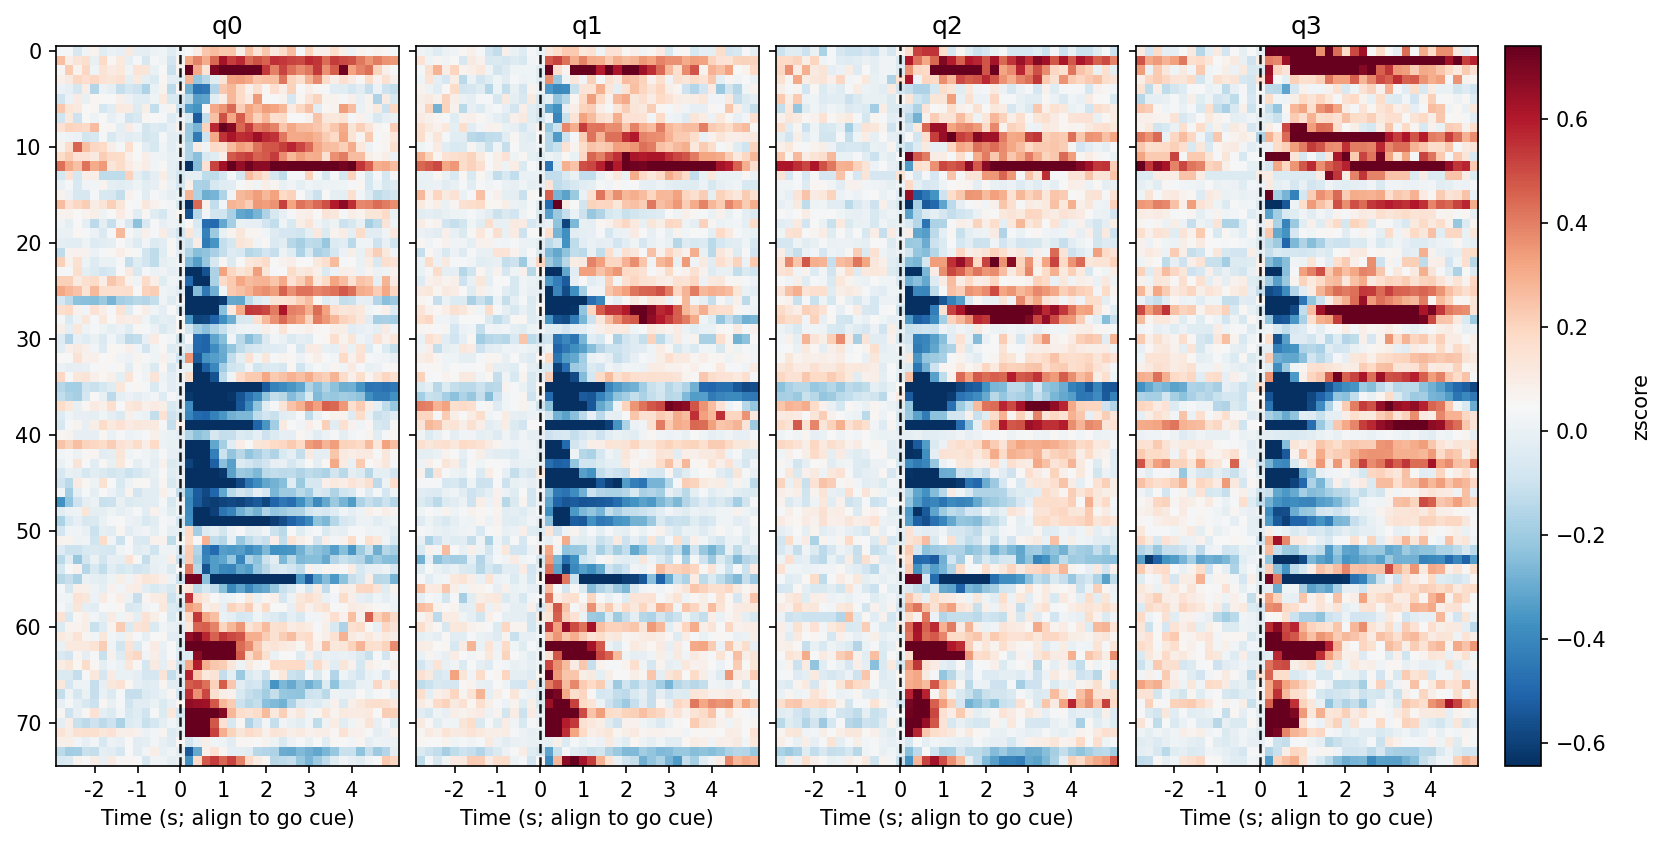

In [59]:
out = plot_clustered_psth_heatmaps_multi_panel(
    df_with_psth,
    value_kind="zscore",
    reference_quantile=0,
    brain_regions=["SI","MA"],
    significant=True,
    alpha=0.05,
    direction="negative",
    monotonic_only=True,          # uses is_monotonic by default for zscore
    time=psth_time,
    #color_range=(-3, 3),
    color_percentile=(2, 98),
    save_path="/root/capsule/scratch/average_psth/heatmaps_zscore_monotonic.png",
)
